# Customer Churn Analysis & Prediction

## Objective
The goal of this project is to analyze customer churn behavior and build a predictive model to identify customers likely to leave a service.

This project combines data analysis, machine learning, and business insights to support decision-making.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

The dataset contains customer information for a telecom company, including:

- Demographics (gender, senior citizen, etc.)
- Account information (tenure, contract type)
- Services used (internet, phone, etc.)
- Billing details (monthly and total charges)

### Target Variable:
- **Churn** → Indicates whether a customer has left the service (1 = Yes, 0 = No)

In [ ]:

# OR if using Drive:
df = pd.read_csv('/content/drive/MyDrive/churn_project/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning & Preprocessing

Steps performed:
- Converted `TotalCharges` to numeric format
- Removed missing values
- Encoded target variable (`Churn`) into binary form

These steps ensure the dataset is suitable for analysis and modeling.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## Exploratory Data Analysis (EDA)

The goal of EDA is to identify patterns and relationships in the data.

Key questions:
- What proportion of customers churn?
- How does contract type affect churn?
- Do higher charges lead to higher churn?

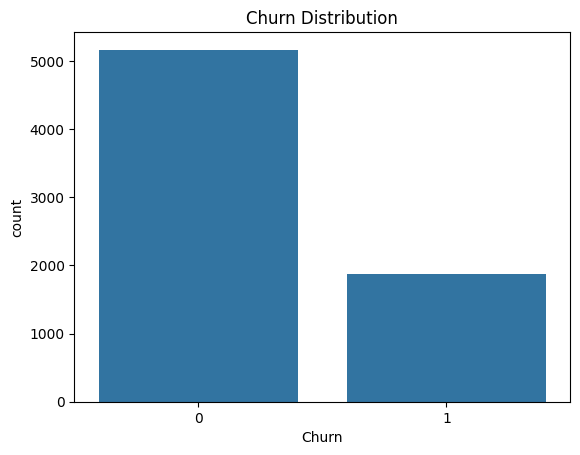

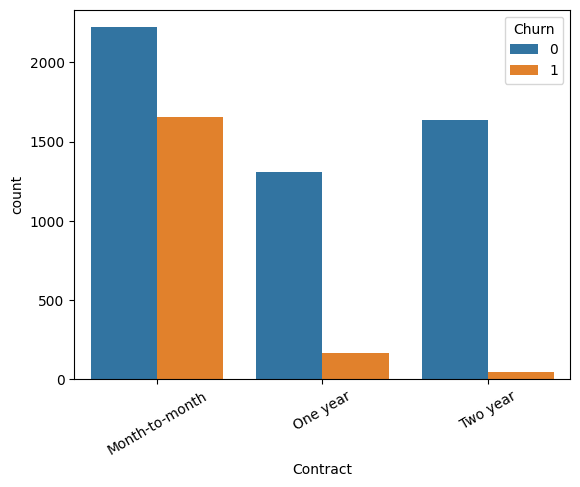

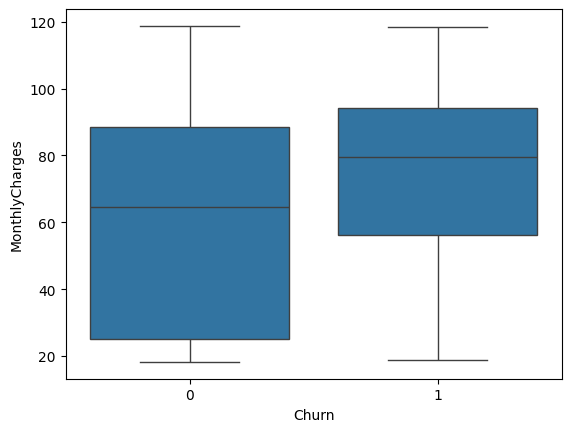

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

## Key Insights from EDA

- Customers with **month-to-month contracts** show significantly higher churn
- Customers with **higher monthly charges** are more likely to churn
- Customers with **short tenure** are at higher risk of leaving

These insights suggest that pricing strategy and contract structure play a major role in retention.

## Feature Encoding

Categorical variables were converted into numerical format using label encoding.

This allows machine learning models to process the data effectively.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

## Model Building

A Random Forest classifier was used to predict customer churn.

Why Random Forest:
- Handles both numerical and categorical data
- Captures non-linear relationships
- Provides feature importance for interpretability

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7924662402274343


## Model Performance

The model was evaluated using accuracy as the primary metric.

The model provides a baseline understanding of churn prediction and identifies key contributing factors.

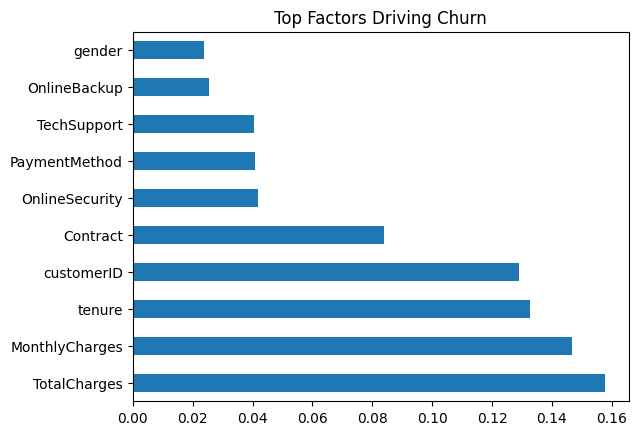

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Factors Driving Churn")
plt.show()

## Feature Importance

Feature importance analysis helps identify the most influential factors driving customer churn.

This is critical for business decision-making, as it highlights areas where intervention is possible.

## Business Insights & Recommendations

Based on the analysis:

- Customers on **month-to-month contracts** should be targeted with retention offers
- High-value customers (high monthly charges) require better service or pricing strategies
- Early-stage customers (low tenure) should be engaged proactively

### Recommendation:
Implement targeted retention strategies to reduce churn and improve customer lifetime value.

In [ ]:
df.to_csv('/content/cleaned_churn_data.csv', index=False)

In [ ]:
from google.colab import files
files.download('/content/cleaned_churn_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This project demonstrates how data analysis and machine learning can be used to identify customer churn patterns and support strategic decision-making.

The combination of predictive modeling and business insights makes this approach applicable to real-world scenarios.